# Backtesting the GARCH(1,1) baseline - silver

Same out-of-sample backtest as notebook 07, for silver. See that notebook for the fuller explanation of each step.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model

## Load data and split into train / test

In [2]:
silver = pd.read_csv("../data/silver_futures.csv", skiprows=[1, 2], index_col=0, parse_dates=True)
silver.index.name = "Date"

returns = silver["Close"].pct_change().dropna() * 100

split_idx = int(len(returns) * 0.8)
split_date = returns.index[split_idx]

print(f"Training period: {returns.index[0].date()} to {returns.index[split_idx - 1].date()} ({split_idx} days)")
print(f"Test period:     {split_date.date()} to {returns.index[-1].date()} ({len(returns) - split_idx} days)")

Training period: 2010-01-05 to 2023-04-11 (3336 days)
Test period:     2023-04-12 to 2026-08-05 (834 days)


## Fit using only the training period

In [3]:
model = arch_model(returns, mean="Constant", vol="Garch", p=1, q=1, dist="normal")
result = model.fit(last_obs=split_date, disp="off")
result.params

mu          0.002775
omega       0.030246
alpha[1]    0.042170
beta[1]     0.950404
Name: params, dtype: float64

## Generate a one-step-ahead forecast for every day in the test period

In [4]:
forecasts = result.forecast(start=split_date, horizon=1, reindex=False)
forecast_variance = forecasts.variance["h.1"]
forecast_volatility = np.sqrt(forecast_variance)
forecast_volatility.head()

Date
2023-04-12    1.868209
2023-04-13    1.868491
2023-04-14    1.864489
2023-04-17    1.850484
2023-04-18    1.819360
Name: h.1, dtype: float64

## Line up each forecast with what actually happened next

In [5]:
next_day_return = returns.shift(-1).loc[forecast_volatility.index]
realized_move = next_day_return.abs()

valid = forecast_volatility.notna() & realized_move.notna()
forecast_volatility = forecast_volatility[valid]
realized_move = realized_move[valid]

comparison = pd.DataFrame({"Forecasted volatility": forecast_volatility, "Actual move (abs return)": realized_move})
comparison.head()

,Forecasted volatility,Actual move (abs return)
Date,,
2023-04-12,1.868209,1.850107
2023-04-13,1.868491,1.739201
2023-04-14,1.864489,1.459252
2023-04-17,1.850484,0.778349
2023-04-18,1.819360,0.467364


## Score it: GARCH vs. a naive "volatility never changes" benchmark

In [6]:
train_returns = returns.loc[:returns.index[split_idx - 1]]
naive_volatility = train_returns.std()

rmse_garch = np.sqrt(np.mean((forecast_volatility - realized_move) ** 2))
rmse_naive = np.sqrt(np.mean((naive_volatility - realized_move) ** 2))

print(f"Naive flat volatility forecast: {naive_volatility:.4f}%")
print(f"GARCH(1,1) RMSE: {rmse_garch:.4f}")
print(f"Naive flat RMSE: {rmse_naive:.4f}")
print(f"GARCH improvement over naive: {(1 - rmse_garch / rmse_naive) * 100:.2f}%")

Naive flat volatility forecast: 1.9458%
GARCH(1,1) RMSE: 2.0044
Naive flat RMSE: 2.0771
GARCH improvement over naive: 3.50%


## Plot forecast vs. reality over the test period

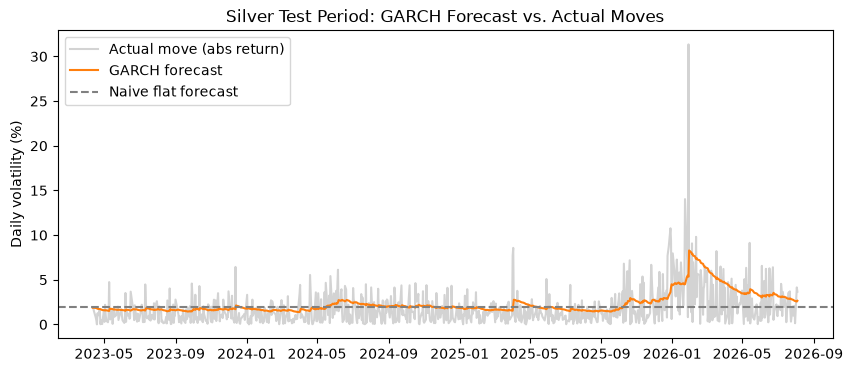

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(realized_move.index, realized_move, color="lightgray", label="Actual move (abs return)")
ax.plot(forecast_volatility.index, forecast_volatility, color="tab:orange", label="GARCH forecast")
ax.axhline(naive_volatility, color="gray", linestyle="--", label="Naive flat forecast")
ax.set_title("Silver Test Period: GARCH Forecast vs. Actual Moves")
ax.set_ylabel("Daily volatility (%)")
ax.legend()
plt.show()